In [40]:
import pandas as pd
import numpy as np
df=pd.read_pickle(f"../df24.pkl")
y=df[['dm']]
X=df.drop(columns=['dm'])

In [41]:
from sklearn.model_selection import train_test_split


In [42]:
X_cause=X[['wk_smk',
'wk_alc', 'wk_mvpa_work', 'wk_mvpa_play', 'wk_walk', 'wk_sleep',
'stress', 'wk_break', 'wk_lunch', 'wk_dinner', 'wk_veg1', 'wk_veg2',
'wk_fruit','sex', 'age', 'edu', 'income', 'job']]


X_result=X[['chol', 'hdl', 'tg', 'ldl', 'sbp', 'wt', 'ht', 'wc', 'bmi','glu','hba1c']]



Test Accuracy: 0.9595375722543352


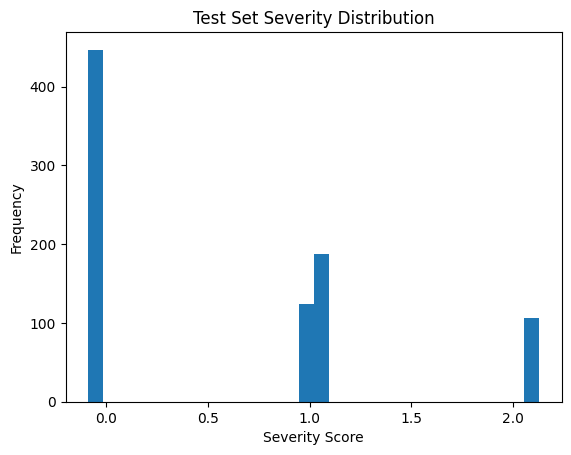

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier


def temperature_scaling(probs, T=2.0):
    # 안정성 위해 log-space 처리
    log_probs = np.log(probs + 1e-12)
    scaled_log_probs = log_probs / T
    scaled_probs = np.exp(scaled_log_probs)
    scaled_probs /= scaled_probs.sum(axis=1, keepdims=True)
    return scaled_probs

# =========================
# 1. Train / Test split
# =========================

X_cause_tr, X_cause_te, \
X_result_tr, X_result_te, \
y_tr, y_te = train_test_split(
    X_cause, X_result, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# =========================
# 2. OOF 생성 (train에서만)
# =========================

n_train = len(y_tr)

z1_oof = np.zeros(n_train)
z2_oof = np.zeros(n_train)
z3_oof = np.zeros(n_train)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

for train_idx, val_idx in kf.split(X_cause_tr):
    
    y_fold_tr = y_tr.iloc[train_idx]
    
    # cause
    model1 = XGBClassifier(
        objective="multi:softprob",
        num_class=3,
        n_estimators=300,
        learning_rate=0.01,
        max_depth=4,
        eval_metric="mlogloss",
        random_state=42
    )
    model1.fit(X_cause_tr.iloc[train_idx], y_fold_tr)
    z1_oof[val_idx] = model1.predict_proba(
        X_cause_tr.iloc[val_idx]
    ) @ np.array([0,1,2])
    
    # result
    model2 = XGBClassifier(
        objective="multi:softprob",
        num_class=3,
        n_estimators=300,
        learning_rate=0.01,
        max_depth=4,
        eval_metric="mlogloss",
        random_state=42
    )
    model2.fit(X_result_tr.iloc[train_idx], y_fold_tr)
    z2_oof[val_idx] = model2.predict_proba(
        X_result_tr.iloc[val_idx]
    ) @ np.array([0,1,2])
    


# =========================
# 3. Meta 모델 학습 (train)
# =========================

meta_train = pd.DataFrame({
    "z1": z1_oof,
    "z2": z2_oof
})

scaler = StandardScaler()
meta_train_scaled = scaler.fit_transform(meta_train)

meta_model = LinearRegression()

meta_model.fit(meta_train_scaled, y_tr)


# =========================
# 4. Test set 예측
# =========================

# block 모델을 train 전체로 다시 학습

final_model1 = XGBClassifier(objective="multi:softprob",
                             num_class=3,
                             n_estimators=300,
                             learning_rate=0.01,
                             max_depth=4,
                             eval_metric="mlogloss",
                             random_state=42)

final_model2 = XGBClassifier(objective="multi:softprob",
                             num_class=3,
                             n_estimators=300,
                             learning_rate=0.01,
                             max_depth=4,
                             eval_metric="mlogloss",
                             random_state=42)


final_model1.fit(X_cause_tr, y_tr)
final_model2.fit(X_result_tr, y_tr)

z1_test = final_model1.predict(X_cause_te)
z2_test = final_model2.predict(X_result_te)


meta_test = pd.DataFrame({
    "z1": z1_test,
    "z2": z2_test,
})

meta_test_scaled = scaler.transform(meta_test)

severity_test = meta_model.predict(meta_test_scaled)

#y_proba_test = temperature_scaling(y_proba_test, T=4)

y_pred_class = np.clip(np.round(severity_test), 0, 2)

print(
    "Test Accuracy:",
    accuracy_score(y_te, y_pred_class)
)
# =========================
# 5. 히스토그램
# =========================

plt.hist(severity_test, bins=30)
plt.xlabel("Severity Score")
plt.ylabel("Frequency")
plt.title("Test Set Severity Distribution")
plt.show()

In [44]:
coef_df = pd.DataFrame(
    meta_model.coef_,
    columns=["z1", "z2"]
)

coef_df["class"] = meta_model.classes_

print(coef_df)

AttributeError: 'LinearRegression' object has no attribute 'classes_'

In [ ]:

T = 2.0   # 1보다 크게
scaled_proba = temperature_scaling(y_proba_test, T=T)

severity_scaled = scaled_proba @ np.array([0,1,2])


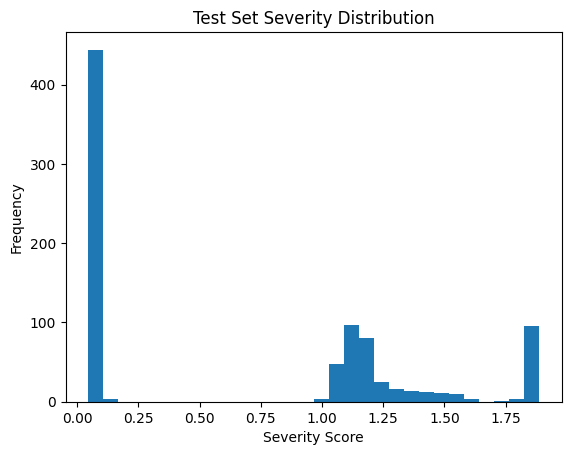

In [ ]:
plt.hist(severity_scaled, bins=30)
plt.xlabel("Severity Score")
plt.ylabel("Frequency")
plt.title("Test Set Severity Distribution")
plt.show()

In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from scipy.stats import chi2


# =========================
# 1️⃣ Feature 구성
# =========================

# Model A: z2만
X_A = pd.DataFrame({
    "z2": z2_oof   # result block
})

# Model B: z1 + z2
X_B = pd.DataFrame({
    "z1": z1_oof,
    "z2": z2_oof
})

y_meta = y_tr   # train 기준


# =========================
# 2️⃣ Scaling
# =========================

scaler_A = StandardScaler()
X_A_scaled = scaler_A.fit_transform(X_A)

scaler_B = StandardScaler()
X_B_scaled = scaler_B.fit_transform(X_B)


# =========================
# 3️⃣ Logistic Regression 학습
# =========================

model_A = LogisticRegression(
    multi_class="multinomial",
    solver="lbfgs",
    max_iter=2000
)
model_A.fit(X_A_scaled, y_meta)

model_B = LogisticRegression(
    multi_class="multinomial",
    solver="lbfgs",
    max_iter=2000
)
model_B.fit(X_B_scaled, y_meta)


# =========================
# 4️⃣ Log-likelihood 계산 함수
# =========================

def log_likelihood(model, X, y):
    proba = model.predict_proba(X)
    ll = 0
    for i in range(len(y)):
        ll += np.log(proba[i, y.iloc[i]])
    return ll


ll_A = log_likelihood(model_A, X_A_scaled, y_meta)
ll_B = log_likelihood(model_B, X_B_scaled, y_meta)


# =========================
# 5️⃣ Likelihood Ratio Test
# =========================

LR_stat = 2 * (ll_B - ll_A)

df_diff = model_B.coef_.size - model_A.coef_.size
p_value = chi2.sf(LR_stat, df_diff)

print("LogLik A:", ll_A)
print("LogLik B:", ll_B)
print("LR statistic:", LR_stat)
print("df difference:", df_diff)
print("p-value:", p_value)

c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\

LogLik A: [-453.01748214]
LogLik B: [-447.37511517]
LR statistic: [11.28473394]
df difference: 3
p-value: [0.01028176]


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss
from sklearn.preprocessing import StandardScaler
import numpy as np
from scipy.stats import chi2


# -------------------------
# Model A: z2 only
# -------------------------

X_A_train = pd.DataFrame({"z2": z2_oof})
X_A_test  = pd.DataFrame({"z2": z2_test})

scaler_A = StandardScaler()
X_A_train_s = scaler_A.fit_transform(X_A_train)
X_A_test_s  = scaler_A.transform(X_A_test)

model_A = LogisticRegression(
    multi_class="multinomial",
    solver="lbfgs",
    max_iter=2000
)
model_A.fit(X_A_train_s, y_tr)

proba_A_test = model_A.predict_proba(X_A_test_s)

logloss_A = log_loss(y_te, proba_A_test)



# -------------------------
# Model B: z1 + z2
# -------------------------

X_B_train = pd.DataFrame({"z1": z1_oof, "z2": z2_oof})
X_B_test  = pd.DataFrame({"z1": z1_test, "z2": z2_test})

scaler_B = StandardScaler()
X_B_train_s = scaler_B.fit_transform(X_B_train)
X_B_test_s  = scaler_B.transform(X_B_test)

model_B = LogisticRegression(
    multi_class="multinomial",
    solver="lbfgs",
    max_iter=2000
)
model_B.fit(X_B_train_s, y_tr)

proba_B_test = model_B.predict_proba(X_B_test_s)

logloss_B = log_loss(y_te, proba_B_test)

print("Test LogLoss A (z2 only):", logloss_A)
print("Test LogLoss B (z1+z2):", logloss_B)
print("Δ LogLoss:", logloss_A - logloss_B)

Test LogLoss A (z2 only): 0.1344488390674574
Test LogLoss B (z1+z2): 0.13180458713112211
Δ LogLoss: 0.0026442519363352734


c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\

In [ ]:
def log_likelihood_from_proba(proba, y):
    ll = 0
    for i in range(len(y)):
        ll += np.log(proba[i, y.iloc[i]])
    return ll


ll_A_test = log_likelihood_from_proba(proba_A_test, y_te)
ll_B_test = log_likelihood_from_proba(proba_B_test, y_te)

LR_stat_test = 2 * (ll_B_test - ll_A_test)

df_diff = model_B.coef_.size - model_A.coef_.size
p_value_test = chi2.sf(LR_stat_test, df_diff)

print("Test LR statistic:", LR_stat_test)
print("Test p-value:", p_value_test)

Test LR statistic: [4.57455585]
Test p-value: [0.20573571]


In [ ]:
from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)

delta_ll_list = []

for train_idx, val_idx in kf.split(X_B_train):

    X_A_tr = X_A_train.iloc[train_idx]
    X_A_val = X_A_train.iloc[val_idx]

    X_B_tr = X_B_train.iloc[train_idx]
    X_B_val = X_B_train.iloc[val_idx]

    y_tr_fold = y_tr.iloc[train_idx]
    y_val_fold = y_tr.iloc[val_idx]

    scalerA = StandardScaler()
    scalerB = StandardScaler()

    XA_tr_s = scalerA.fit_transform(X_A_tr)
    XA_val_s = scalerA.transform(X_A_val)

    XB_tr_s = scalerB.fit_transform(X_B_tr)
    XB_val_s = scalerB.transform(X_B_val)

    mA = LogisticRegression(multi_class="multinomial", max_iter=2000)
    mB = LogisticRegression(multi_class="multinomial", max_iter=2000)

    mA.fit(XA_tr_s, y_tr_fold)
    mB.fit(XB_tr_s, y_tr_fold)

    llA = log_likelihood_from_proba(mA.predict_proba(XA_val_s), y_val_fold)
    llB = log_likelihood_from_proba(mB.predict_proba(XB_val_s), y_val_fold)

    delta_ll_list.append(llB - llA)

delta_ll_mean = np.mean(delta_ll_list)
delta_ll_std  = np.std(delta_ll_list)

print("CV mean ΔLL:", delta_ll_mean)
print("CV std ΔLL:", delta_ll_std)

c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\

CV mean ΔLL: 0.8873904494812066
CV std ΔLL: 1.2931252533044335


In [ ]:
from sklearn.metrics import accuracy_score, classification_report

# =========================
# 1. Feature / Target 선택
# =========================

X = df[["glu", "hba1c"]]
y = df["dm"]   # 0,1,2


# =========================
# 2. Train / Test split
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# =========================
# 3. XGBoost 모델 정의
# =========================

model = XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    eval_metric="mlogloss",
    random_state=42
)


# =========================
# 4. 학습
# =========================

model.fit(X_train, y_train)


# =========================
# 5. 예측
# =========================

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


# =========================
# 6. Severity score (optional)
# =========================

severity_score = y_proba @ np.array([0, 1, 2])

print("Severity score sample:")
print(severity_score[:10])

Accuracy: 0.9560693641618497
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       445
           1       0.90      0.98      0.94       281
           2       0.95      0.77      0.85       139

    accuracy                           0.96       865
   macro avg       0.95      0.92      0.93       865
weighted avg       0.96      0.96      0.95       865

Severity score sample:
[1.04409108e+00 1.05393239e+00 5.93149033e-03 1.02409234e+00
 1.03671741e+00 1.00772125e+00 1.99967977e+00 3.50883335e-03
 8.51135323e-04 1.03070400e+00]


In [ ]:
from sklearn.metrics import accuracy_score, classification_report

# =========================
# 1. Feature / Target 선택
# =========================

X = df[['chol', 'hdl', 'tg', 'ldl', 'sbp', 'wt', 'ht', 'wc', 'bmi','glu','hba1c','wk_smk',
'wk_alc', 'wk_mvpa_work', 'wk_mvpa_play', 'wk_walk', 'wk_sleep',
'stress', 'wk_break', 'wk_lunch', 'wk_dinner', 'wk_veg1', 'wk_veg2',
'wk_fruit','sex', 'age', 'edu', 'income', 'job']]
y = df["dm"]   # 0,1,2


# =========================
# 2. Train / Test split
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# =========================
# 3. XGBoost 모델 정의
# =========================

model = XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    eval_metric="mlogloss",
    random_state=42
)


# =========================
# 4. 학습
# =========================

model.fit(X_train, y_train)


# =========================
# 5. 예측
# =========================

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


# =========================
# 6. Severity score (optional)
# =========================

severity_score = y_proba @ np.array([0, 1, 2])

print("Severity score sample:")
print(severity_score[:10])

Accuracy: 0.9560693641618497
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       445
           1       0.91      0.97      0.94       281
           2       0.93      0.78      0.85       139

    accuracy                           0.96       865
   macro avg       0.94      0.92      0.93       865
weighted avg       0.96      0.96      0.95       865

Severity score sample:
[1.03251876e+00 1.04543766e+00 7.92276138e-03 1.00608299e+00
 1.04030596e+00 1.00571778e+00 1.99850184e+00 3.25476976e-04
 3.66795377e-03 1.01195807e+00]
